In [4]:
import torch
import torch.nn as nn

In [5]:
class LSTM:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.wf = torch.randn(hidden_size, input_size + hidden_size)
        self.wi = torch.randn(hidden_size, input_size + hidden_size)
        self.wc = torch.randn(hidden_size, input_size + hidden_size)
        self.wo = torch.randn(hidden_size, input_size + hidden_size)
        self.wy = torch.randn(output_size, hidden_size)
        self.bias_f = torch.randn(hidden_size)
        self.bias_i = torch.randn(hidden_size)
        self.bias_c = torch.randn(hidden_size)
        self.bias_o = torch.randn(hidden_size)
        self.bias_y = torch.randn(output_size)

    def forward(self, x):
        h_prev = torch.zeros(self.hidden_size)
        c_prev = torch.zeros(self.hidden_size)
        self.h_list = [h_prev]
        self.c_list = [c_prev]
        self.y_list = []
        self.x_list = []
        self.f_list = []
        self.i_list = []
        self.c_tilde_list = []
        self.o_list = []

        for t in range(x.size(0)):
            x_t = x[t]
            combined = torch.cat((x_t, h_prev), dim=0)

            f_t = torch.sigmoid(torch.matmul(self.wf, combined) + self.bias_f)
            i_t = torch.sigmoid(torch.matmul(self.wi, combined) + self.bias_i)
            c_tilde_t = torch.tanh(torch.matmul(self.wc, combined) + self.bias_c)
            c_t = f_t * c_prev + i_t * c_tilde_t
            o_t = torch.sigmoid(torch.matmul(self.wo, combined) + self.bias_o)
            h_t = o_t * torch.tanh(c_t)
            y_t = torch.matmul(self.wy, h_t) + self.bias_y
            h_prev = h_t
            c_prev = c_t
            self.h_list.append(h_t)
            self.c_list.append(c_t)
            self.y_list.append(y_t)
            self.x_list.append(x_t)
            self.f_list.append(f_t)
            self.i_list.append(i_t)
            self.c_tilde_list.append(c_tilde_t)
            self.o_list.append(o_t)

        return torch.stack(self.y_list, dim=0)

    def backward(self, x, y):
            h_future = torch.zeros(self.hidden_size)
            c_future = torch.zeros(self.hidden_size)
            
            # FIX 1: Initialize accumulators
            dw_f = torch.zeros_like(self.wf)
            dw_i = torch.zeros_like(self.wi)
            dw_c = torch.zeros_like(self.wc)
            dw_o = torch.zeros_like(self.wo)
            dw_y = torch.zeros_like(self.wy)
            
            db_f = torch.zeros_like(self.bias_f)
            db_i = torch.zeros_like(self.bias_i)
            db_c = torch.zeros_like(self.bias_c)
            db_o = torch.zeros_like(self.bias_o)
            db_y = torch.zeros_like(self.bias_y)
    
            for t in reversed(range(x.size(0))):
                x_t = x[t]
                h_t = self.h_list[t + 1]
                c_t = self.c_list[t + 1]
                y_t = self.y_list[t]
                o_t = self.o_list[t]
                c_tilde_t = self.c_tilde_list[t]
    
                dy = y_t - y[t]
    
                dh = torch.matmul(self.wy.t(), dy) + h_future
                
                # FIX 1: Accumulate output weights
                dw_y += torch.matmul(dy.unsqueeze(1), h_t.unsqueeze(0))
                db_y += dy
    
                do = dh * torch.tanh(c_t)
                dc = dh * o_t * (1 - torch.tanh(c_t) ** 2) + c_future
    
                di = dc * c_tilde_t
                df = dc * self.c_list[t]
    
                dzf = df * self.f_list[t] * (1 - self.f_list[t])
                dzi = di * self.i_list[t] * (1 - self.i_list[t])
                dzc_tilde = dc * self.i_list[t] * (1 - c_tilde_t ** 2)
                dzo = do * o_t * (1 - o_t)
    
                combined = torch.cat((x_t, self.h_list[t]), dim=0).unsqueeze(0)
    
                # FIX 1: Accumulate with +=
                dw_f += torch.matmul(dzf.unsqueeze(1), combined)
                dw_i += torch.matmul(dzi.unsqueeze(1), combined)
                dw_c += torch.matmul(dzc_tilde.unsqueeze(1), combined)
                dw_o += torch.matmul(dzo.unsqueeze(1), combined)
    
                db_f += dzf
                db_i += dzi
                db_c += dzc_tilde
                db_o += dzo
    
                # FIX 2: Calculate combined gradient and slice it
                dz_concat = (torch.matmul(self.wf.t(), dzf) + 
                             torch.matmul(self.wi.t(), dzi) + 
                             torch.matmul(self.wc.t(), dzc_tilde) + 
                             torch.matmul(self.wo.t(), dzo))
                
                # Since you concatenated (x, h), h is at the end.
                h_future = dz_concat[self.input_size:] 
                c_future = dc * self.f_list[t]
    
            return dw_f, dw_i, dw_c, dw_o, db_f, db_i, db_c, db_o, dw_y, db_y
    
    def update_weights(self, dw_f, dw_i, dw_c, dw_o, db_f, db_i, db_c, db_o, dw_y, db_y, learning_rate):
        self.wf -= learning_rate * dw_f
        self.wi -= learning_rate * dw_i
        self.wc -= learning_rate * dw_c
        self.wo -= learning_rate * dw_o
        self.wy -= learning_rate * dw_y
        self.bias_f -= learning_rate * db_f
        self.bias_i -= learning_rate * db_i
        self.bias_c -= learning_rate * db_c
        self.bias_o -= learning_rate * db_o
        self.bias_y -= learning_rate * db_y
    

In [8]:
import torch.optim as optim
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.wf = nn.Parameter(torch.randn(hidden_size, input_size + hidden_size))
        self.wi = nn.Parameter(torch.randn(hidden_size, input_size + hidden_size))
        self.wc = nn.Parameter(torch.randn(hidden_size, input_size + hidden_size))
        self.wo = nn.Parameter(torch.randn(hidden_size, input_size + hidden_size))
        self.wy = nn.Parameter(torch.randn(output_size, hidden_size))

        self.bias_f = nn.Parameter(torch.randn(hidden_size))
        self.bias_i = nn.Parameter(torch.randn(hidden_size))
        self.bias_c = nn.Parameter(torch.randn(hidden_size))
        self.bias_o = nn.Parameter(torch.randn(hidden_size))
        self.bias_y = nn.Parameter(torch.randn(output_size))

    def forward(self, x):
        h_prev = torch.zeros(self.wf.size(0))
        c_prev = torch.zeros(self.wf.size(0))
        y_list = []

        for t in range(x.size(0)):
            x_t = x[t]
            combined = torch.cat((x_t, h_prev), dim=0)

            f_t = torch.sigmoid(torch.matmul(self.wf, combined) + self.bias_f)
            i_t = torch.sigmoid(torch.matmul(self.wi, combined) + self.bias_i)
            c_tilde_t = torch.tanh(torch.matmul(self.wc, combined) + self.bias_c)
            c_t = f_t * c_prev + i_t * c_tilde_t
            o_t = torch.sigmoid(torch.matmul(self.wo, combined) + self.bias_o)
            h_t = o_t * torch.tanh(c_t)
            y_t = torch.matmul(self.wy, h_t) + self.bias_y

            h_prev = h_t
            c_prev = c_t
            y_list.append(y_t)

        return torch.stack(y_list, dim=0)

In [9]:
seq_length = 5
input_size = 3
hidden_size = 8
output_size = 2
epochs = 200
learning_rate = 0.05
torch.manual_seed(42)
x_data = torch.randn(seq_length, input_size)
y_target = torch.randn(seq_length, output_size)

model = LSTMModel(input_size, hidden_size, output_size)
loss = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print("Torch LSTM Model Initialized.")
print("Starting Training...")
print("-" * 30)

# 4. The Training Loop
for epoch in range(epochs):
    # Step A: Forward Pass
    optimizer.zero_grad()
    y_pred = model.forward(x_data)
    step_loss = loss(y_pred, y_target)
    step_loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {step_loss:.4f}")

print("-" * 30)
print("Training Complete. Final Loss:", f"{step_loss:.6f}")
print("-" * 30)
print("-" * 30)
print("Starting Custom Model Training for Comparison...")
model_ = LSTM(input_size, hidden_size, output_size)
print("Starting Training...")
print("-" * 30)

for epoch in range(epochs):
    y_pred = model_.forward(x_data)
    loss = 0.5 * torch.sum((y_pred - y_target) ** 2).item()
    gradients = model_.backward(x_data, y_target)
    model_.update_weights(*gradients, learning_rate)
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f}")
print(f"- Training Complete. Final Loss: {loss:.6f}")
print("-" * 30) 

Torch LSTM Model Initialized.
Starting Training...
------------------------------
Epoch   0 | Loss: 2.9367
Epoch  20 | Loss: 0.5121
Epoch  40 | Loss: 0.3556
Epoch  60 | Loss: 0.2714
Epoch  80 | Loss: 0.2125
Epoch 100 | Loss: 0.1669
Epoch 120 | Loss: 0.1294
Epoch 140 | Loss: 0.0984
Epoch 160 | Loss: 0.0736
Epoch 180 | Loss: 0.0544
------------------------------
Training Complete. Final Loss: 0.040554
------------------------------
------------------------------
Starting Custom Model Training for Comparison...
Starting Training...
------------------------------
Epoch   0 | Loss: 6.7674
Epoch  20 | Loss: 0.7508
Epoch  40 | Loss: 0.3961
Epoch  60 | Loss: 0.2497
Epoch  80 | Loss: 0.1528
Epoch 100 | Loss: 0.0892
Epoch 120 | Loss: 0.0502
Epoch 140 | Loss: 0.0276
Epoch 160 | Loss: 0.0150
Epoch 180 | Loss: 0.0082
- Training Complete. Final Loss: 0.004579
------------------------------


Starting Real Data Training...
Epoch  0 | Avg MSE Loss: 0.5468
Epoch  5 | Avg MSE Loss: 0.1812
Epoch 10 | Avg MSE Loss: 0.1722
Epoch 15 | Avg MSE Loss: 0.1687
Epoch 20 | Avg MSE Loss: 0.1653
Epoch 25 | Avg MSE Loss: 0.1618

Training Complete! Evaluating on Test Data...


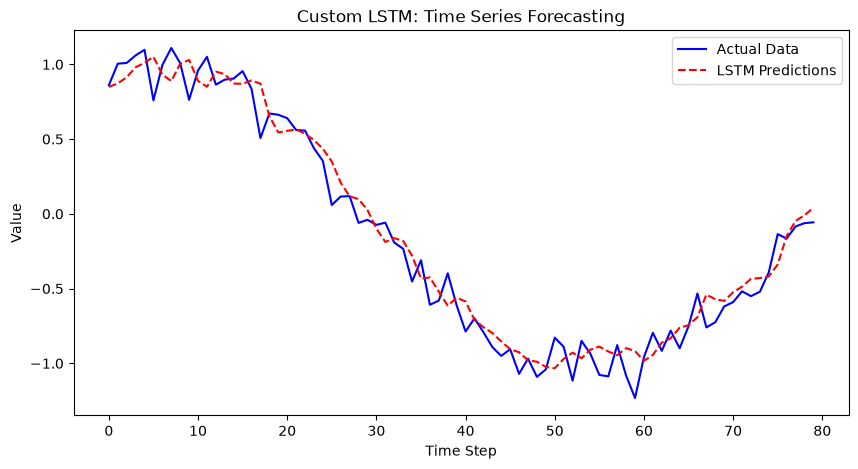

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
import math
import matplotlib.pyplot as plt

# ==========================================
# 1. THE DATASET (Sliding Window Time Series)
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        # Total number of sequences we can extract
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        # X: The sequence of data
        # Y: The same sequence shifted one step into the future
        x = self.data[idx : idx + self.seq_length]
        y = self.data[idx + 1 : idx + self.seq_length + 1]
        
        # Reshape to (seq_length, input_size) where input_size=1
        return x.unsqueeze(1), y.unsqueeze(1)

# Generate a "Real" Dataset: A noisy sine wave
total_data_points = 500
x_axis = torch.linspace(0, 10 * math.pi, total_data_points)
# Sine wave + a little bit of random noise
raw_data = torch.sin(x_axis) + 0.1 * torch.randn(total_data_points)

# ==========================================
# 2. THE DATALOADER PIPELINE
# ==========================================
seq_length = 20
batch_size = 16

# Split into Training (80%) and Testing (20%)
train_size = int(total_data_points * 0.8)
train_data = raw_data[:train_size]
test_data = raw_data[train_size:]

# Create Dataset and DataLoader objects
train_dataset = TimeSeriesDataset(train_data, seq_length)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TimeSeriesDataset(test_data, seq_length)
# Note: we usually don't shuffle test data so we can plot it chronologically!
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# ==========================================
# 3. INITIALIZE YOUR CUSTOM LSTM
# ==========================================
# (Make sure your LSTM class code is pasted above this!)
input_size = 1   # 1 feature (the wave amplitude)
hidden_size = 16 # Memory capacity
output_size = 1  # Predicting 1 future value
learning_rate = 0.01
epochs = 30

model = LSTM(input_size, hidden_size, output_size)

# ==========================================
# 4. THE TRAINING LOOP
# ==========================================
print("Starting Real Data Training...")
for epoch in range(epochs):
    epoch_loss = 0.0
    
    # Iterate over the DataLoader batches
    for batch_x, batch_y in train_loader:
        
        # Because your custom LSTM handles one sequence at a time, 
        # we loop through the sequences in this batch.
        for i in range(batch_x.size(0)):
            x_seq = batch_x[i] # Shape: (seq_length, 1)
            y_seq = batch_y[i] # Shape: (seq_length, 1)
            
            # Forward Pass
            y_pred = model.forward(x_seq)
            
            # Accumulate Loss for logging
            loss = 0.5 * torch.sum((y_pred - y_seq) ** 2).item()
            epoch_loss += loss
            
            # Backward Pass
            grads = model.backward(x_seq, y_seq)
            
            # Optimizer Step
            model.update_weights(*grads, learning_rate)
            
    # Calculate average loss per sequence
    avg_loss = epoch_loss / len(train_dataset)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | Avg MSE Loss: {avg_loss:.4f}")

# ==========================================
# 5. EVALUATION AND VISUALIZATION
# ==========================================
print("\nTraining Complete! Evaluating on Test Data...")

predictions = []
actuals = []

# During evaluation, we don't calculate gradients or update weights
for x_seq, y_seq in test_loader:
    x_seq = x_seq[0] # Remove batch dimension
    y_seq = y_seq[0]
    
    # Forward pass
    y_pred = model.forward(x_seq)
    
    # We only care about the very last prediction in the sequence
    predictions.append(y_pred[-1].item())
    actuals.append(y_seq[-1].item())

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(actuals, label='Actual Data', color='blue')
plt.plot(predictions, label='LSTM Predictions', color='red', linestyle='dashed')
plt.title('Custom LSTM: Time Series Forecasting')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()